# HeST Trace Event Viewer

Interactive viewer for pytesdaq-format HDF5 traces produced by `hest_trace_generation.py`.  
Browse events, inspect individual channel waveforms, view a 24-sensor energy heatmap, and overlay the original HeST truth data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
import matplotlib.colors as mcolors
import h5py
from pytesdaq.io import H5Reader
from ipywidgets import interact, IntSlider, Dropdown, Checkbox
%matplotlib inline

/home/dkodroff/miniforge3/envs/pythonstandard/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backends is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/home/dkodroff/miniforge3/envs/pythonstandard/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


## Configuration

Set paths to the generated trace directory and (optionally) the original HeST H5 file.

In [ ]:
# --- USER CONFIG ---

# path to pytesdaq output from hest_trace_generation.py
TRACE_PATH = '../outputs/continuous_I9_D20260921_T160335/'  
# optional: path to original HeST .h5 for truth overlay
HEST_H5_PATH = '../inputs/Spectrum_Flat_ER_energyMin_10_energyMax_10000_nEvents_100_Heraldv1.h5'          
# Filter file
FILTER_PATH = '../inputs/herald_filter.hdf5'
# sampling frequency (Hz)
FS = 1.25e6 
# Sensor channels                 
N_CHANNELS = 24

## Load traces

~ 1 minute for 10 traces (with 24 sensors each)

In [105]:
reader = H5Reader()
reader.set_files(TRACE_PATH)

events = []
event_metadata = []
while True:
    traces, meta = reader.read_next_event(include_metadata=True, adctoamp=True)
    if meta['error_msg'] == 'No more files available':
        break
    events.append(traces.copy())
    event_metadata.append(meta)
reader.close()

n_events = len(events)
print(f'Loaded {n_events} events')
if n_events > 0:
    print(f'Trace shape: {events[0].shape}  ({events[0].shape[0]} channels, {events[0].shape[1]} samples)')

Loaded 10 events
Trace shape: (24, 12500000)  (24 channels, 12500000 samples)


## Load HeST truth (optional)

In [106]:
hest_data = None
if HEST_H5_PATH is not None:
    hest_data = h5py.File(HEST_H5_PATH, 'r')
    print(f'HeST file loaded: {hest_data.attrs["n_events"]} events, '
          f'{hest_data.attrs["n_sensors"]} sensors')
else:
    print('No HeST file specified (set HEST_H5_PATH to enable truth overlay)')

HeST file loaded: 100 events, 24 sensors


## HeRALD v1 sensor layout

The 24 sensors are arranged in a hex-packed 6x6 grid (with corners removed).  
This cell builds the (x, y) positions and grid indices for the heatmap display.

In [107]:
ARRAY_MAP = np.array([[0,0,1,1,0,0],
                      [0,1,1,1,1,0],
                      [1,1,1,1,1,1],
                      [1,1,1,1,1,1],
                      [0,1,1,1,1,0],
                      [0,0,1,1,0,0]])
PITCH = 1.1  # cm

sensor_positions = {}  # sensor_id -> (x, y) in cm
sensor_grid = {}       # sensor_id -> (row, col) in array_map
sid = 0
for i in range(6):
    for j in range(6):
        if ARRAY_MAP[i, j] > 0.5:
            sensor_positions[sid] = ((i - 2.5) * PITCH, (j - 2.5) * PITCH)
            sensor_grid[sid] = (i, j)
            sid += 1

print(f'{len(sensor_positions)} sensors mapped')

24 sensors mapped


## Helper functions

In [15]:
def get_time_axis(n_samples, fs=FS):
    """Return time axis in milliseconds."""
    return np.arange(n_samples) / fs * 1e3


def get_pulse_amplitude(trace):
    """Estimate pulse amplitude as max - baseline (first 10% median)."""
    baseline_samples = max(1, len(trace) // 10)
    baseline = np.median(trace[:baseline_samples])
    return np.max(np.abs(trace - baseline))


def get_hest_truth(event_idx):
    """Extract per-sensor total energy from the HeST H5 for one event."""
    if hest_data is None:
        return None, None
    evt_key = str(event_idx)
    if evt_key not in hest_data['events']:
        return None, None
    evt = hest_data['events'][evt_key]
    recoil_energy = evt.attrs['recoil_energy']
    recoil_type = evt.attrs['recoil_type']
    sensor_energies = np.zeros(N_CHANNELS)
    for ch_key in ['singlet', 'triplet', 'ir', 'qp']:
        if ch_key not in evt:
            continue
        ch_grp = evt[ch_key]
        weight = ch_grp.attrs.get('weight', 1.0)
        for s in range(N_CHANNELS):
            s_key = str(s)
            if s_key in ch_grp:
                sensor_energies[s] += np.sum(ch_grp[s_key]['energies'][:]) * weight
    return {'recoil_energy': recoil_energy, 'recoil_type': recoil_type,
            'sensor_energies': sensor_energies}, None

## Plot: All 24 channels for a single event

~ 1.5 minutes for 10 events (24 sensors)

In [111]:
def plot_all_channels(event_idx=0):
    """Plot all 24 channel traces stacked vertically."""
    if event_idx >= n_events:
        print(f'Event {event_idx} out of range (max {n_events - 1})')
        return
    traces = events[event_idx]
    n_ch, n_samp = traces.shape
    t_ms = get_time_axis(n_samp)

    fig, axes = plt.subplots(6, 4, figsize=(16, 18), sharex=True)
    fig.suptitle(f'Event {event_idx} — All channels', fontsize=14)

    truth, _ = get_hest_truth(event_idx)
    if truth is not None:
        fig.suptitle(
            f'Event {event_idx} — {truth["recoil_type"]} recoil, '
            f'E = {truth["recoil_energy"]:.1f} eV',
            fontsize=14)

    for ch in range(min(n_ch, N_CHANNELS)):
        ax = axes[ch // 4, ch % 4]
        ax.plot(t_ms, traces[ch] * 1e6, linewidth=0.3, color='C0')
        ax.set_ylabel(f'ch {ch:02d}', fontsize=8)
        ax.tick_params(labelsize=7)
    axes[-1, 0].set_xlabel('Time (ms)')
    axes[-1, 1].set_xlabel('Time (ms)')
    axes[-1, 2].set_xlabel('Time (ms)')
    axes[-1, 3].set_xlabel('Time (ms)')
    fig.text(0.04, 0.5, 'Current (µA)', va='center', rotation='vertical', fontsize=12)
    plt.tight_layout(rect=[0.05, 0, 1, 0.97])
    plt.show()


interact(plot_all_channels,
         event_idx=IntSlider(min=0, max=max(0, n_events - 1), step=1, value=0,
                             description='Event'));

interactive(children=(IntSlider(value=0, description='Event', max=9), Output()), _dom_classes=('widget-interac…

# Plot Single Event, Single Sensor, with truth information

Event 0: ER recoil, E_recoil = 6388.07 eV
Sensor 3 hits:
  Channel     # hits  Total E (eV)  Mean t (µs)  Min t (µs)  Max t (µs)
  --------------------------------------------------------------------
  singlet          2       32.0000      5000.00     5000.00     5000.00
  triplet          1       16.0000     57000.00    57000.00    57000.00
  ir               2        2.0000      5000.00     5000.00     5000.00
  qp              14        2.9053      5548.19     5238.68     7865.24


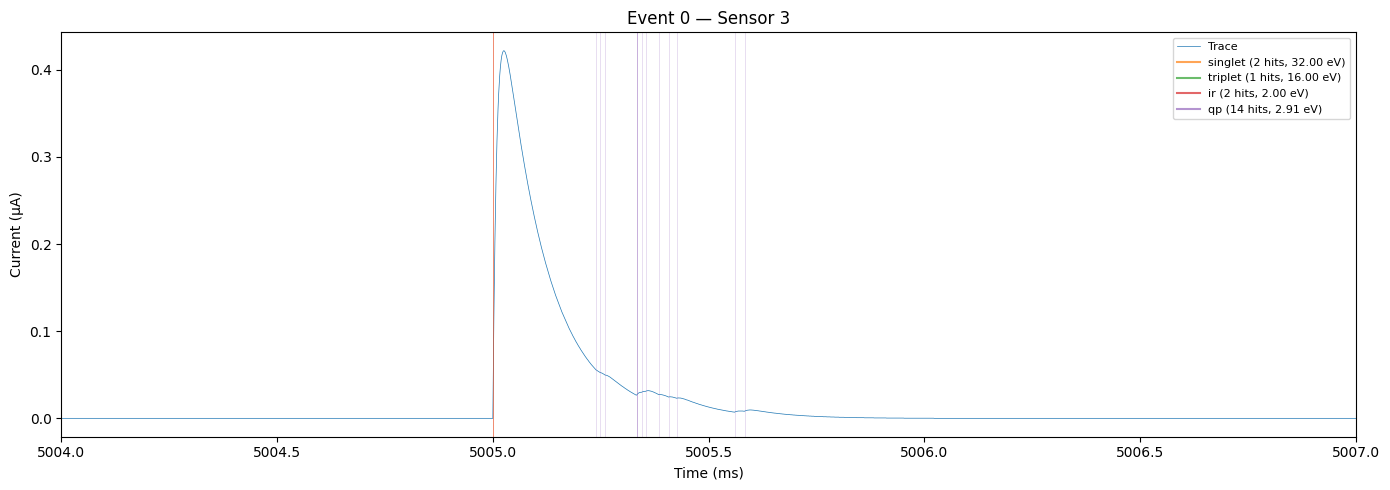

In [124]:
def plot_sensor_with_truth(event_idx=0, sensor_idx=0, pretrigger_ms=5):
    """Plot a single sensor trace and print HeST truth hits."""
    if event_idx >= n_events:
        print(f'Event {event_idx} out of range (max {n_events - 1})')
        return

    trace = events[event_idx][sensor_idx]
    t_ms = get_time_axis(len(trace))

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(t_ms, trace * 1e6, linewidth=0.5, color='C0', label='Trace')

    # Collect and print HeST truth hits
    hit_info = []
    if hest_data is not None:
        evt_key = str(event_idx)
        if evt_key in hest_data['events']:
            evt = hest_data['events'][evt_key]
            recoil_e = evt.attrs['recoil_energy']
            recoil_t = evt.attrs['recoil_type']
            print(f'Event {event_idx}: {recoil_t} recoil, E_recoil = {recoil_e:.2f} eV')
            print(f'Sensor {sensor_idx} hits:')
            print(f'  {"Channel":<10} {"# hits":>7} {"Total E (eV)":>13} '
                  f'{"Mean t (µs)":>12} {"Min t (µs)":>11} {"Max t (µs)":>11}')
            print('  ' + '-' * 68)

            colors = {'singlet': 'C1', 'triplet': 'C2', 'ir': 'C3', 'qp': 'C4'}
            for ch_key in ['singlet', 'triplet', 'ir', 'qp']:
                if ch_key not in evt:
                    continue
                ch_grp = evt[ch_key]
                s_key = str(sensor_idx)
                if s_key not in ch_grp:
                    continue
                weight = ch_grp.attrs.get('weight', 1.0)
                times_us = ch_grp[s_key]['arrival_times'][:] + (pretrigger_ms*1e3)
                energies = ch_grp[s_key]['energies'][:] * weight
                total_e = np.sum(energies)
                n_hits = len(times_us)

                print(f'  {ch_key:<10} {n_hits:>7} {total_e:>13.4f} '
                      f'{np.mean(times_us):>12.2f} {np.min(times_us):>11.2f} '
                      f'{np.max(times_us):>11.2f}')

                # Mark arrival times on the trace
                hit_times_ms = times_us * 1e-3 + (len(trace) / FS * 1e3) / 2
                for ht in hit_times_ms[:50]:  # limit markers for readability
                    ax.axvline(ht, color=colors[ch_key], alpha=0.3, lw=0.5)
                ax.axvline(np.nan, color=colors[ch_key], alpha=0.7, lw=1.5,
                           label=f'{ch_key} ({n_hits} hits, {total_e:.2f} eV)')

                hit_info.append((ch_key, n_hits, total_e))

            if not hit_info:
                print('  (no hits on this sensor)')
    else:
        print('No HeST file loaded — set HEST_H5_PATH for truth overlay')

    ax.set_xlim(5004,5007)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Current (µA)')
    ax.set_title(f'Event {event_idx} — Sensor {sensor_idx}')
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()


event_idx = 0 
sensor_idx = 3
pretrigger_ms = 5

plot_sensor_with_truth(event_idx=event_idx, sensor_idx=sensor_idx, pretrigger_ms=pretrigger_ms)


## Plot: Sensor heatmap

Shows the pulse amplitude (or integrated energy) on each sensor in the HeRALD v1 physical layout.

In [125]:
def plot_sensor_heatmap(event_idx=0, use_truth=False):
    """Heatmap of per-sensor amplitude in the physical sensor layout."""
    if event_idx >= n_events:
        print(f'Event {event_idx} out of range')
        return

    if use_truth:
        truth, _ = get_hest_truth(event_idx)
        if truth is None:
            print('No HeST truth data available')
            return
        values = truth['sensor_energies']
        label = 'Deposited energy (eV)'
        title_extra = f' [TRUTH: {truth["recoil_type"]}, E={truth["recoil_energy"]:.1f} eV]'
    else:
        traces = events[event_idx]
        values = np.array([get_pulse_amplitude(traces[i]) for i in range(N_CHANNELS)])
        values *= 1e6  # to µA
        label = 'Pulse amplitude (µA)'
        title_extra = ''

    fig, ax = plt.subplots(1, 1, figsize=(7, 7))

    vmax = np.max(values) if np.max(values) > 0 else 1
    norm = mcolors.Normalize(vmin=0, vmax=vmax)
    cmap = plt.cm.inferno

    patches = []
    colors = []
    for sid in range(N_CHANNELS):
        x, y = sensor_positions[sid]
        rect = Rectangle((x - 0.5, y - 0.5), 1.0, 1.0)
        patches.append(rect)
        colors.append(values[sid])
        ax.text(x, y, f'{sid}', ha='center', va='center',
                fontsize=8, color='white' if values[sid] > vmax * 0.5 else 'black')

    pc = PatchCollection(patches, cmap=cmap, norm=norm)
    pc.set_array(np.array(colors))
    pc.set_edgecolor('gray')
    pc.set_linewidth(0.5)
    ax.add_collection(pc)

    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal')
    ax.set_xlabel('x (cm)')
    ax.set_ylabel('y (cm)')
    ax.set_title(f'Event {event_idx} — Sensor map{title_extra}')

    cbar = fig.colorbar(pc, ax=ax, shrink=0.8)
    cbar.set_label(label)
    plt.tight_layout()
    plt.show()


interact(plot_sensor_heatmap,
         event_idx=IntSlider(min=0, max=max(0, n_events - 1), step=1, value=0,
                             description='Event'),
         use_truth=Checkbox(value=False, description='Show HeST truth'));

interactive(children=(IntSlider(value=0, description='Event', max=9), Checkbox(value=False, description='Show …